# Notebook d'Exploration

## Import des Librairies et de la Data

In [1]:
# Import des librairies nécessaires

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Import du fichier CSV contenant les avis

df = pd.read_csv('avis_40k.csv', sep=';')
df.head(10)

,auteur,note,titre,commentaire,date_experience,date_avis,url,texteServiceReply,dateServiceReply,dataServiceReply
0,FREDERIC (Bordeaux),4,Produit conforme,Produit conforme. La description du contenue e...,"February 13, 2026",A day ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
1,Patrice,5,Comportement professionnel,NaN,"February 11, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
2,Client daniel,4,R.A.S,..............R.A.S.........,"January 31, 2026",3 days ago,https://www.trustpilot.com/review/oscaro.com,NaN,NaN,NaN
3,Derek Mcmillan,5,Excellent.,NaN,"February 4, 2026","Feb 4, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 5, 2026","Bonjour Derek, Je vous remercie pour votre ret..."
4,GM,4,Tres bien mais attention bien scotcher…,Tres bien mais attention bien scotcher les col...,"January 30, 2026","Feb 1, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Feb 3, 2026","Bonjour Grégoire , Je vous remercie pour votre..."
5,eric petitot,4,Piece conforme mais la gaine de…,Piece conforme mais la gaine de protection sur...,"January 23, 2026","Jan 24, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Jan 27, 2026","Bonjour Eric, Je vous remercie pour votre reto..."
6,Anis Ourajini,5,Very good.,Very good experience.,"January 21, 2026","Jan 22, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Jan 27, 2026","Bonjour Anis, Merci pour votre message ! Nous ..."
7,Masnou Bruno,5,Super.....................,NaN,"January 15, 2026","Jan 16, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Jan 20, 2026","Bonjour Bruno, Je vous remercie pour votre ret..."
8,Peter Rowden,5,Prompt delivery,Prompt delivery,"January 14, 2026","Jan 15, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Jan 16, 2026","Bonjour Peter, Je vous remercie pour votre ret..."
9,Moha,5,Enjoliveur par choc,"Simple, rapide et efficace.","January 11, 2026","Jan 12, 2026",https://www.trustpilot.com/review/oscaro.com,Reply from Oscaro,"Jan 14, 2026","Bonjour Mohamed, Je vous remercie pour votre r..."


## Data Cleaning

In [3]:
##Gestion des doublons

doublons = df.duplicated().sum()
print(f"Il y a {doublons} doublons dans transactions.")

Il y a 20 doublons dans transactions.


In [4]:
# Suppression des doublons

df = df.drop_duplicates(keep='first')

In [5]:
# Gestion des valeures manquantes
df.isna().sum()


auteur                  0
note                    0
titre                   0
commentaire          3774
date_experience         0
date_avis               0
url                     0
texteServiceReply    6854
dateServiceReply     6854
dataServiceReply     6854
dtype: int64

In [6]:
# Remplacons les commentaires vides par leur titre
df['commentaire'] = df['commentaire'].fillna(df['titre'])

#Revérifions les valeurs manquantes 

df.isna().sum()

auteur                  0
note                    0
titre                   0
commentaire             0
date_experience         0
date_avis               0
url                     0
texteServiceReply    6854
dateServiceReply     6854
dataServiceReply     6854
dtype: int64

## WORD CLOUD avec Stopwords

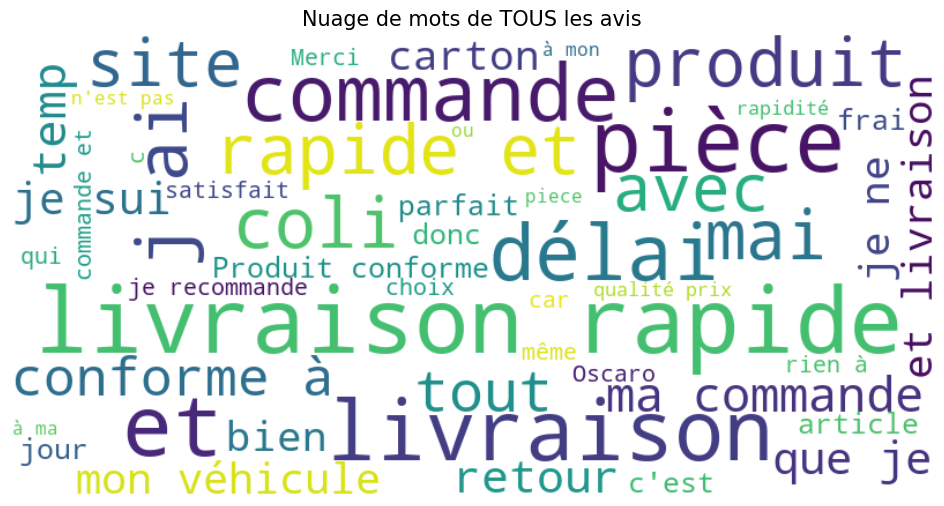

In [7]:
### Nuage de mots

from wordcloud import WordCloud, STOPWORDS

def generate_wordcloud(data, note_max=5):
    """
    Affiche un nuage de mots pour tous les avis ayant une note <= note_max.
    """
    # 1. Filtrage par seuil
    subset = data[data['note'] <= note_max]

    # Sécurité si le subset est vide
    if subset.empty:
        print(f"Aucun avis trouvé avec une note inférieure ou égale à {note_max}.")
        return

    # 2. Titre dynamique pour la clarté
    if note_max == 5:
        titre = "Nuage de mots de TOUS les avis"
        couleur = "viridis"
    elif note_max <= 2:
        titre = f"Focus sur l'insatisfaction (Notes <= {note_max}/5)"
        couleur = "Reds" # Rouge pour le négatif
    else:
        titre = f"Avis avec note <= {note_max}/5"
        couleur = "YlOrBr" # Orange pour le neutre/moyen

    # 3. Préparation du texte
    text = " ".join(str(review) for review in subset.commentaire)
    
    # 4. Stopwords (on utilise ta liste enrichie)
    mots_inutiles = set(STOPWORDS)
    mots_inutiles.update(["le", "la", "les", "de", "des", "un", "une", "du", "pour", "dans", 
                          "en", "ce", "ces", "est", "a", "au", "aux", "sur", "plus", "très"])

    # 5. Création du WordCloud
    # On change la couleur (colormap) selon la note pour le style !
    #couleur = "Reds" if note_selectionnee and note_selectionnee <= 2 else "GnBu"
    
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color='white',
        stopwords=mots_inutiles,
        max_words=50,
        colormap=couleur
    ).generate(text)

    # 6. Affichage
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(titre, fontsize=15)
    plt.axis("off")
    plt.show()

# --- TEST DANS LE NOTEBOOK ---
# Pour voir les mots des avis 1 étoile :
generate_wordcloud(df, note_max=5)


### Text Cleaning avec NLTK

In [8]:
#Import nécessaire au nettoyage des données en vue du projet de ML NLP

import sys

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import re

nltk.download('punkt')
nltk.download('stopwords')

# Charger la liste française
french_stopwords = set(stopwords.words('french'))

[nltk_data] Downloading package punkt to /Users/marvin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marvin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
#Créons la fonction de nettoyage des données textuelles
import nltk

# Téléchargement des ressources manquantes
nltk.download('punkt')
nltk.download('punkt_tab') # Parfois nécessaire selon la version
nltk.download('stopwords')

def clean_text(text):
    # 1. Mise en minuscules
    text = str(text).lower()
    
    # 2. Suppression de la ponctuation et des caractères spéciaux (regex)
    # On garde les lettres et on enlève le reste
    text = re.sub(r'[^a-zàâçéèêëîïôûù\s]', '', text)
    
    # 3. Tokenization (couper le texte en mots)
    tokens = word_tokenize(text, language='french')
    
    # 4. Suppression des Stopwords (mots vides) français
    stop_words = set(stopwords.words('french'))
    # On peut ajouter des mots spécifiques à Trustpilot ici
    stop_words.update(['avis', 'client', 'commande', 'site', 'plus']) 
    
    cleaned_tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    
    return " ".join(cleaned_tokens)

# Application sur tout le DataFrame
df['commentaire_nltk'] = df['commentaire'].apply(clean_text)

[nltk_data] Downloading package punkt to /Users/marvin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/marvin/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/marvin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
#Verification du résultat

df['commentaire_nltk'] = df['commentaire'].apply(clean_text)
print(df['commentaire_nltk'].head())

0    produit conforme description contenue ambiguë ...
1                           comportement professionnel
2                                                  ras
3                                            excellent
4    tres bien attention bien scotcher colis derniè...
Name: commentaire_nltk, dtype: str


## WORD CLOUD après NLTK Clean

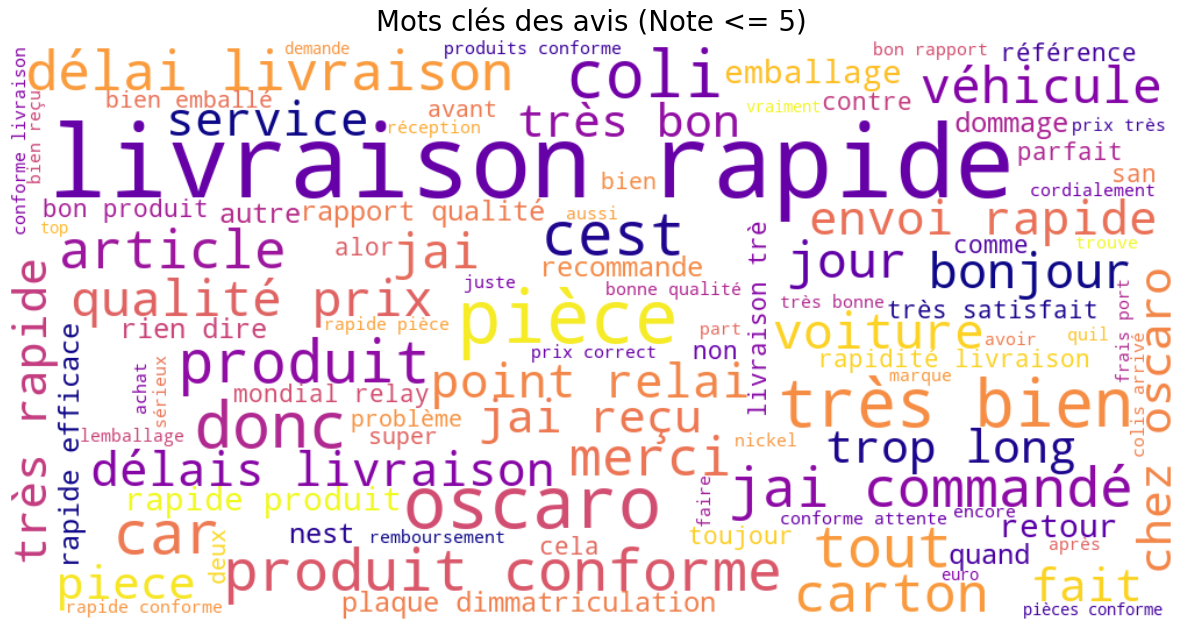

In [12]:
# Nouveau nuage de mots après nettoyage
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def display_wordcloud(data, note_max=5):
    """
    Fonction réutilisable pour le Notebook et Streamlit.
    Filtre les avis selon la note maximale choisie.
    """
    # 1. Filtrage
    subset = data[data['note'] <= note_max]
    
    if subset.empty:
        print(f"Aucun avis pour la note <= {note_max}")
        return
    
    # 2. Préparation du texte (on utilise la colonne clean) 
    # On gère les NaN au cas où
    text_clean = " ".join(review for review in subset.commentaire_nltk.astype(str) if review != 'nan')

    # 3. Configuration du nuage
    # Petite astuce : on change la couleur selon la note !
    color = 'plasma' if note_max > 3 else 'Reds'

    wc = WordCloud(
        width=1000, 
        height=500, 
        background_color='white',
        max_words=100,
        colormap=color
    ).generate(text_clean)

    # 4. Affichage
    plt.figure(figsize=(15, 8))
    # C'est ici que l'on place l'interpolation pour rendre l'image plus nette
    plt.imshow(wc, interpolation='bilinear') 
    plt.axis("off")
    plt.title(f"Mots clés des avis (Note <= {note_max})", fontsize=20)
    plt.show()

# --- TEST DANS LE NOTEBOOK ---
# Affiche les mots des avis négatifs (1 et 2 étoiles)
display_wordcloud(df, note_max=5)


In [13]:
# Sauvegarde du DataFrame nettoyé pour une utilisation future
df.to_csv('avis_40k_clean.csv', index=False, sep=';')